# Anova Test

In [9]:
import pandas as pd
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split

data={
    'CGPA':[8.5, 7.2, 6.8, 9.1, 5.5, 7.8, 8.2, 6.1, 9.5, 7.0,8.0, 6.5, 7.5, 8.8, 5.8, 9.2, 7.3, 6.9, 8.6, 7.1],
    'Internship':[3, 1, 0, 4, 0, 2, 3, 1, 4, 1, 2, 0, 2, 3, 0, 4, 1, 1, 3, 2],
    'Projects':[5, 2, 1, 6, 1, 3, 4, 2, 7, 2, 3, 1, 3, 5, 1, 6, 2, 2, 5, 3],
    'AptitudeScore': [85, 60, 55, 92, 40, 70, 78, 50, 95, 58, 72, 48, 65, 88, 42, 90, 62, 56, 82, 60],
    'Placed':[1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
}
df=pd.DataFrame(data)
X=df.drop(columns='Placed')
Y=df['Placed']
X.head()
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)



In [6]:
Y.head()

0    1
1    0
2    0
3    1
4    0
Name: Placed, dtype: int64

In [ ]:
sel=SelectKBest(f_classif, k=2).fit(X_train,Y_train)
X_train.columns[sel.get_support()]
columns=X_train.columns[sel.get_support()]
X_train=sel.transform(X_train)
X_test=sel.transform(X_test)

X_train=pd.DataFrame(X_train,columns=columns)
X_test=pd.DataFrame(X_test,columns=columns)
X_train.head()


,CGPA,AptitudeScore
0,9.5,95.0
1,7.8,70.0
2,6.5,48.0
3,9.1,92.0
4,8.6,82.0


In [12]:
X_train['Placed']=Y_train.values
X_train.head()

,CGPA,AptitudeScore,Placed
0,9.5,95.0,1
1,7.8,70.0,1
2,6.5,48.0,0
3,9.1,92.0,1
4,8.6,82.0,1


## Chi Square

In [8]:
import pandas as pd
from scipy.stats import chi2_contingency

import pandas as pd

data = {
    'Gender': ['M', 'F', 'F', 'M', 'F', 'M', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F'],
    'Education': ['UG', 'PG', 'UG', 'PG', 'UG', 'PG', 'UG', 'PG', 'PG', 'UG', 'PG', 'UG', 'PG', 'UG', 'UG', 'PG', 'UG', 'PG', 'PG', 'UG'],
    'City': ['Urban', 'Rural', 'Urban', 'Urban', 'Rural', 'Urban', 'Rural', 'Urban', 'Urban', 'Rural', 'Urban', 'Rural', 'Urban', 'Rural', 'Urban', 'Rural', 'Urban', 'Urban', 'Rural', 'Urban'],
    'Purchased': [1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0]
}

df = pd.DataFrame(data)
contingency_table = pd.crosstab(df['Gender'],df['Purchased'])
chi2_contingency(contingency_table)
contingency_table
# results=[]
# for feauture in df.columns[:-1]:
#     contingency_table = pd.crosstab(df[feauture], df['Purchased'])
#     p_value= chi2_contingency(contingency_table)[1]
#     results.append(p_value)

table=pd.crosstab(df['City'],df['Purchased'])
table

Purchased,0,1
City,,
Rural,7,1
Urban,2,10


<Axes: >

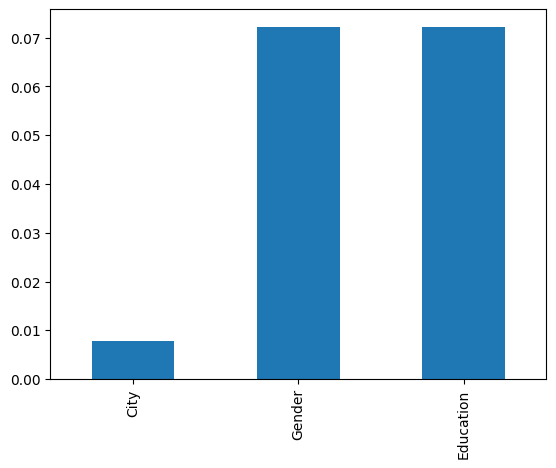

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/rakumar2601/Library/Python/3.13/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Users/rakumar2601/Library/Python/3.13/lib/python/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/rakumar2601/Library/Python/3.13/lib/python/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/rakumar2601/Library/Python/3.13/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Users/rakumar2601/Library/Python/3.13/l

In [6]:
pd.Series(results,index=df.columns[:-1]).sort_values().plot(kind='bar')